In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [4]:
df=pd.read_csv('/Users/hebah/Olist_Project/Output/master_data.csv')
print('Shape:',df.shape)
print('\nFirst look:')

Shape: (118390, 15)

First look:


In [5]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,payment_type,payment_value,review_score,price,freight_value,product_category_name_english
0,03e5d6a8dd520898f86f8429ccd07c21,72b319c928f3d04322db2e904d91a611,shipped,2018-07-30 11:51:13,2018-07-31 12:31:25,NaN,2018-08-16 00:00:00,rio de janeiro,RJ,voucher,46.80,3.0,119.90,15.94,health_beauty
1,03e5d6a8dd520898f86f8429ccd07c21,72b319c928f3d04322db2e904d91a611,shipped,2018-07-30 11:51:13,2018-07-31 12:31:25,NaN,2018-08-16 00:00:00,rio de janeiro,RJ,voucher,46.80,3.0,119.90,15.94,health_beauty
2,03e5d6a8dd520898f86f8429ccd07c21,72b319c928f3d04322db2e904d91a611,shipped,2018-07-30 11:51:13,2018-07-31 12:31:25,NaN,2018-08-16 00:00:00,rio de janeiro,RJ,voucher,42.24,3.0,119.90,15.94,health_beauty
3,037540b18a708608c766355696a57467,a35401291a0580dbcef88f14d8938900,delivered,2017-11-28 10:46:46,2017-11-28 10:55:03,2017-12-13 00:22:38,2017-12-21 00:00:00,videira,SC,credit_card,115.35,1.0,98.90,16.45,computers_accessories
4,044406a115a855072a8e79d38f028a80,c2fd07c064da726f771496f47be85d7f,delivered,2017-08-01 11:04:50,2017-08-02 03:04:31,2017-08-10 17:34:49,2017-08-28 00:00:00,canoas,RS,boleto,71.14,1.0,56.99,14.15,perfumery


In [6]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_city', 'customer_state',
       'payment_type', 'payment_value', 'review_score', 'price',
       'freight_value', 'product_category_name_english'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118390 entries, 0 to 118389
Data columns (total 15 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118390 non-null  str    
 1   customer_id                    118390 non-null  str    
 2   order_status                   118390 non-null  str    
 3   order_purchase_timestamp       118390 non-null  str    
 4   order_approved_at              118370 non-null  str    
 5   order_delivered_customer_date  115712 non-null  str    
 6   order_estimated_delivery_date  118390 non-null  str    
 7   customer_city                  118390 non-null  str    
 8   customer_state                 118390 non-null  str    
 9   payment_type                   118390 non-null  str    
 10  payment_value                  118390 non-null  float64
 11  review_score                   117413 non-null  float64
 12  price                          117737 non

In [8]:
df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  20
order_delivered_customer_date    2678
order_estimated_delivery_date       0
customer_city                       0
customer_state                      0
payment_type                        0
payment_value                       0
review_score                      977
price                             653
freight_value                     653
product_category_name_english    2370
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(12435)

In [10]:
print("\nOrder status types:")
print(df['order_status'].value_counts())


Order status types:
order_status
delivered      115720
shipped          1256
unavailable       652
invoiced          378
processing        376
created             5
approved            3
Name: count, dtype: int64


In [11]:
# Fix dates
date_cols = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'order_approved_at'
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col])


df = df.drop_duplicates(subset='order_id')

df['review_score'] = df['review_score'].fillna(0)
df['product_category_name_english'] = df['product_category_name_english'].fillna('Unknown')
df['payment_type'] = df['payment_type'].fillna('Unknown')

print("Cleaning done! Shape now:", df.shape)

Cleaning done! Shape now: (98815, 15)


In [12]:
#Delivery delay
df['delivery_delay_days']=(df['order_delivered_customer_date']-df['order_estimated_delivery_date']).dt.days

#Total order value
df['total_order_value']=df['price']+ df['freight_value']

#Month-Year
df['purchase_month_year'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

#Late or On Time
df['delivery_status'] = df['delivery_delay_days'].apply(
    lambda x: 'Late' if x > 0 else ('On Time' if pd.notnull(x) else 'Unknown')
)

#Customer satisfaction
df['satisfaction'] = df['review_score'].apply(
    lambda x: 'Happy' if x >= 4 else ('Neutral' if x == 3 else ('Unhappy' if x > 0 else 'No Review'))
)
print("New columns added:")
print(df[['delivery_delay_days','total_order_value',
          'delivery_status','satisfaction']].head())


New columns added:
   delivery_delay_days  total_order_value delivery_status satisfaction
0                  NaN             135.84         Unknown      Neutral
3                 -8.0             115.35         On Time      Unhappy
4                -18.0              71.14         On Time      Unhappy
5                -25.0             181.30         On Time      Neutral
6                 -5.0              93.80         On Time        Happy


In [13]:
# CELL 6 — Funnel Data
funnel_data = pd.DataFrame({
    'Stage': [
        '1 - Orders Placed',
        '2 - Approved',
        '3 - Shipped',
        '4 - Delivered',
        '5 - Reviewed'
    ],
    'Count': [
        len(df),
        len(df[df['order_status'].isin(['approved','processing','shipped','delivered','invoiced'])]),
        len(df[df['order_status'].isin(['shipped','delivered'])]),
        len(df[df['order_status'] == 'delivered']),
        len(df[(df['order_status'] == 'delivered') & (df['review_score'] > 0)])
    ]
})

funnel_data['drop_off_%'] = (
    (funnel_data['Count'].shift(1) - funnel_data['Count']) /
    funnel_data['Count'].shift(1) * 100
).round(1)

print("YOUR FUNNEL:")
print(funnel_data)

YOUR FUNNEL:
               Stage  Count  drop_off_%
0  1 - Orders Placed  98815         NaN
1       2 - Approved  98201         0.6
2        3 - Shipped  97584         0.6
3      4 - Delivered  96477         1.1
4       5 - Reviewed  95831         0.7


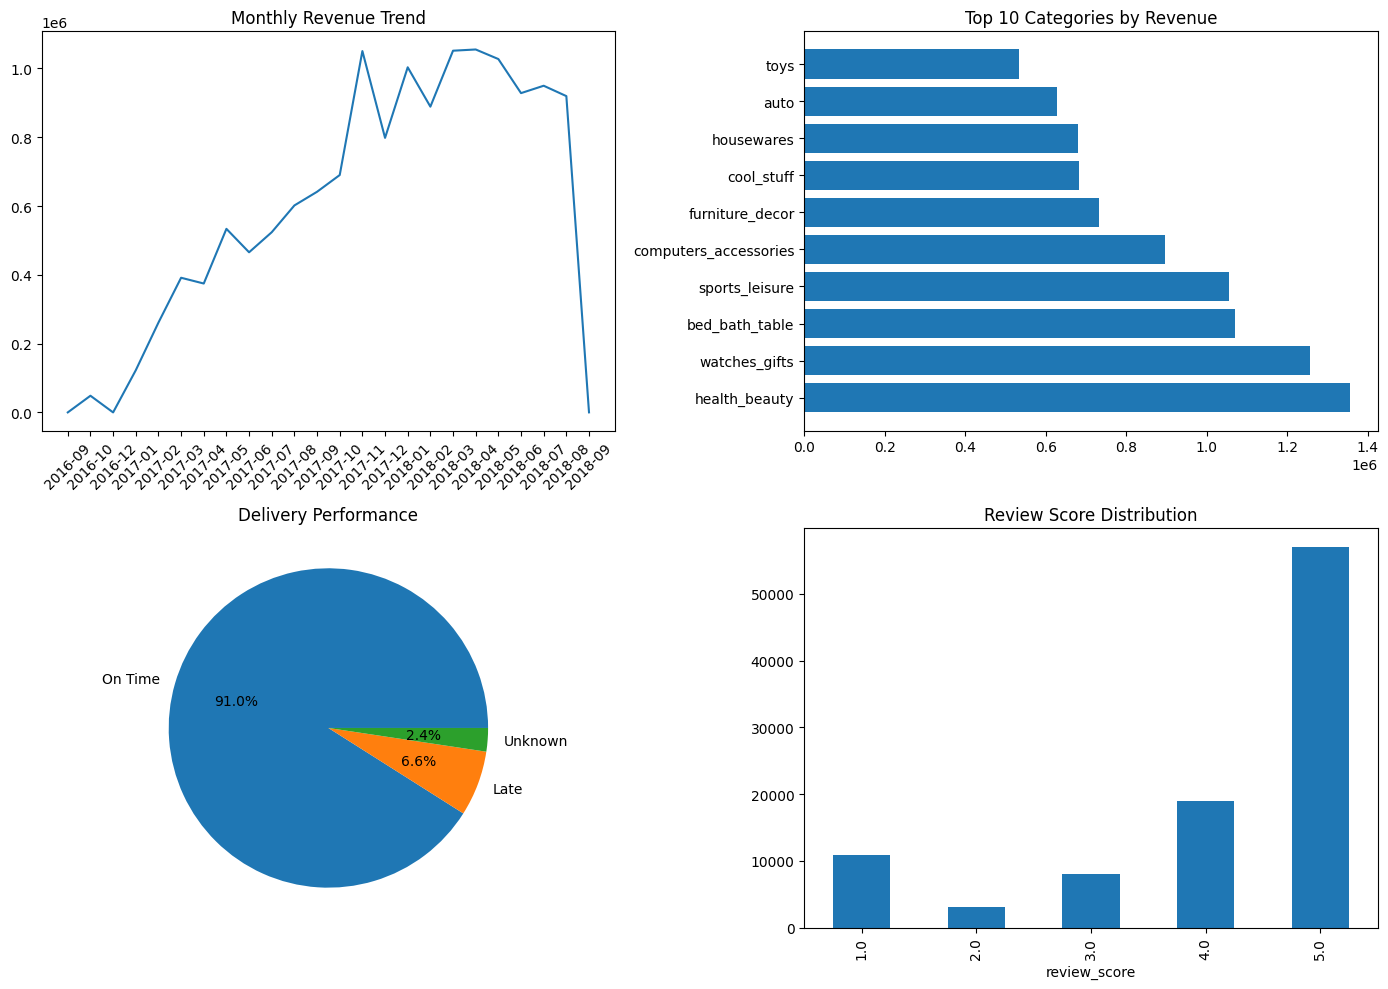

Charts saved!


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Here we are looking for Monthly Revenue
monthly = df.groupby('purchase_month_year')['total_order_value'].sum()
axes[0,0].plot(monthly.index, monthly.values)
axes[0,0].set_title('Monthly Revenue Trend')
axes[0,0].tick_params(axis='x', rotation=45)

# Top 10 Categories
top_cat = df.groupby('product_category_name_english')['total_order_value'].sum().nlargest(10)
axes[0,1].barh(top_cat.index, top_cat.values)
axes[0,1].set_title('Top 10 Categories by Revenue')

# Delivery Status
delivery_counts = df['delivery_status'].value_counts()
axes[1,0].pie(delivery_counts.values, labels=delivery_counts.index, autopct='%1.1f%%')
axes[1,0].set_title('Delivery Performance')

# Review Score Distribution
df[df['review_score'] > 0]['review_score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1,1])
axes[1,1].set_title('Review Score Distribution')

plt.tight_layout()
plt.savefig('eda_charts.png')
plt.show()
print("Charts saved!")

In [21]:
# Export for Power BI
df.to_csv('/Users/hebah/Olist_Project/cleaned_master.csv', index=False)
funnel_data.to_csv('/Users/hebah/Olist_Project/funnel_data.csv', index=False)

print("Files ready for Power BI!")
print("cleaned_master.csv —", len(df), "rows")
print("funnel_data.csv —", len(funnel_data), "rows")

Files ready for Power BI!
cleaned_master.csv — 98815 rows
funnel_data.csv — 5 rows
